# Gowalla Dataset Exploration

Exploratory data analysis of the Gowalla dataset used in the LightGCN paper.

**Reference:** He et al., *LightGCN: Simplifying and Powering Graph Convolution Network for Recommendation*, SIGIR 2020.

**Expected stats from paper (Table 2):**
- Users: 29,858
- Items: 40,981
- Interactions: 1,027,370
- Density: 0.00084

## 1. Loading the Data

Before we can analyze anything, we need to read the raw files into Python.

Each line in `train.txt` and `test.txt` represents one user and all the places they checked in to:
```
user_id  item_id1  item_id2  item_id3  ...
```
The first number is the user's ID, and everything after it is the list of item IDs they interacted with.

We store the result in two structures:
- `user_items` — a dictionary mapping each user to their list of items (used later for evaluation)
- `pairs` — a flat list of `(user, item)` tuples (used to build the graph matrix)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os
from pathlib import Path

# --- path setup ---
if Path("/content").exists():
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/LightGCN-Recommender")
    DATA_PATH = Path("/content/drive/MyDrive/ZED_project_data/gowalla")
else:
    PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path(os.getcwd())
    DATA_PATH = PROJECT_ROOT / "data" / "gowalla"

TRAIN_FILE = DATA_PATH / "train.txt"
TEST_FILE  = DATA_PATH / "test.txt"

print(f"Project root : {PROJECT_ROOT}")
print(f"Train exists : {TRAIN_FILE.exists()}")
print(f"Test exists  : {TEST_FILE.exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root : /content/LightGCN-Recommender
Train exists : True
Test exists  : True


## 2. Basic Statistics

The most important sanity check in the whole notebook: **do our numbers match Table 2 from the paper?**

If they don't match, it means we have the wrong dataset, a corrupted file, or a bug in loading —
and anything we build on top of it (the model, the experiments) would be invalid.

We also compute **density** — the fraction of all possible user-item pairs that actually have an interaction.
Density = total interactions / (n_users × n_items). Here it is 0.00084, meaning only 0.084% of pairs
are known. This extreme sparsity is the core challenge that LightGCN is designed to solve.

In [17]:
def load_interactions(filepath):
    user_items = {}
    pairs = []
    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            user_id = int(parts[0])
            item_ids = [int(x) for x in parts[1:]]
            user_items[user_id] = item_ids
            for item_id in item_ids:
                pairs.append((user_id, item_id))
    return user_items, pairs

train_user_items, train_pairs = load_interactions(TRAIN_FILE)
test_user_items,  test_pairs  = load_interactions(TEST_FILE)

print(f"Train — users: {len(train_user_items):,}, interactions: {len(train_pairs):,}")
print(f"Test  — users: {len(test_user_items):,},  interactions: {len(test_pairs):,}")

Train — users: 29,858, interactions: 810,128
Test  — users: 29,858,  interactions: 217,242


## 3. Interactions per User

We want to know how active users are — how many places did each user check in to during training?

We expect a **long-tail distribution**: the vast majority of users have very few interactions (say, 8–20),
while a small number of power users have hundreds. This is typical of real-world datasets.

Why does this matter for LightGCN? Users with very few interactions are the hardest to make good
recommendations for — the model has little information about them. This is the classic
**cold-start problem** in recommender systems.

We plot both a linear and a log-log scale. On a log-log plot, a long-tail distribution becomes
a roughly straight line — this is called a **power law** and is a signature of organic human behavior data.

In [18]:
all_users = set(train_user_items.keys()) | set(test_user_items.keys())

all_items_train = {item for items in train_user_items.values() for item in items}
all_items_test  = {item for items in test_user_items.values()  for item in items}
all_items = all_items_train | all_items_test

n_users        = len(all_users)
n_items        = len(all_items)
n_train        = len(train_pairs)
n_test         = len(test_pairs)
n_interactions = n_train + n_test
density        = n_interactions / (n_users * n_items)

print("=" * 45)
print(f"  Users        : {n_users:>10,}   (paper: 29,858)")
print(f"  Items        : {n_items:>10,}   (paper: 40,981)")
print(f"  Train inter. : {n_train:>10,}")
print(f"  Test  inter. : {n_test:>10,}")
print(f"  Total inter. : {n_interactions:>10,}   (paper: 1,027,370)")
print(f"  Density      : {density:>10.5f}   (paper: 0.00084)")
print("=" * 45)

  Users        :     29,858   (paper: 29,858)
  Items        :     40,981   (paper: 40,981)
  Train inter. :    810,128
  Test  inter. :    217,242
  Total inter. :  1,027,370   (paper: 1,027,370)
  Density      :    0.00084   (paper: 0.00084)


Min interactions per user : 8
Max interactions per user : 811
Mean                      : 27.1
Median                    : 16.0


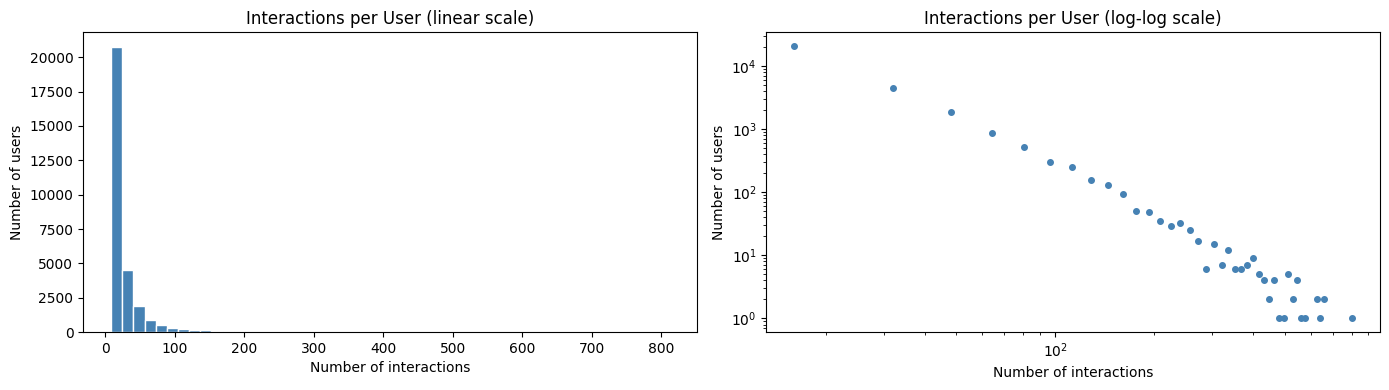

In [19]:
user_degrees = np.array([len(items) for items in train_user_items.values()])

print(f"Min interactions per user : {user_degrees.min()}")
print(f"Max interactions per user : {user_degrees.max()}")
print(f"Mean                      : {user_degrees.mean():.1f}")
print(f"Median                    : {np.median(user_degrees):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_degrees, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Interactions per User (linear scale)")
axes[0].set_xlabel("Number of interactions")
axes[0].set_ylabel("Number of users")

counts, edges = np.histogram(user_degrees, bins=50)
centers = (edges[:-1] + edges[1:]) / 2
axes[1].loglog(centers[counts > 0], counts[counts > 0], "o", color="steelblue", markersize=4)
axes[1].set_title("Interactions per User (log-log scale)")
axes[1].set_xlabel("Number of interactions")
axes[1].set_ylabel("Number of users")

plt.tight_layout()
plt.show()

## 4. Interactions per Item

Now we flip the perspective: instead of asking "how active is each user?", we ask
"how popular is each item?"

Again we expect a long-tail: a handful of places in Gowalla were visited by thousands of people
(tourist landmarks, popular restaurants), while the majority of places were visited by only 1–3 people.

This is called **popularity bias** and it is a known problem in recommender systems —
a naive model would just recommend the most popular items to everyone, which is not useful.
LightGCN addresses this by learning personalized embeddings for every user and item separately,
so niche items can still surface for the right users.

Min interactions per item : 1
Max interactions per item : 1415
Mean                      : 19.8
Median                    : 12.0


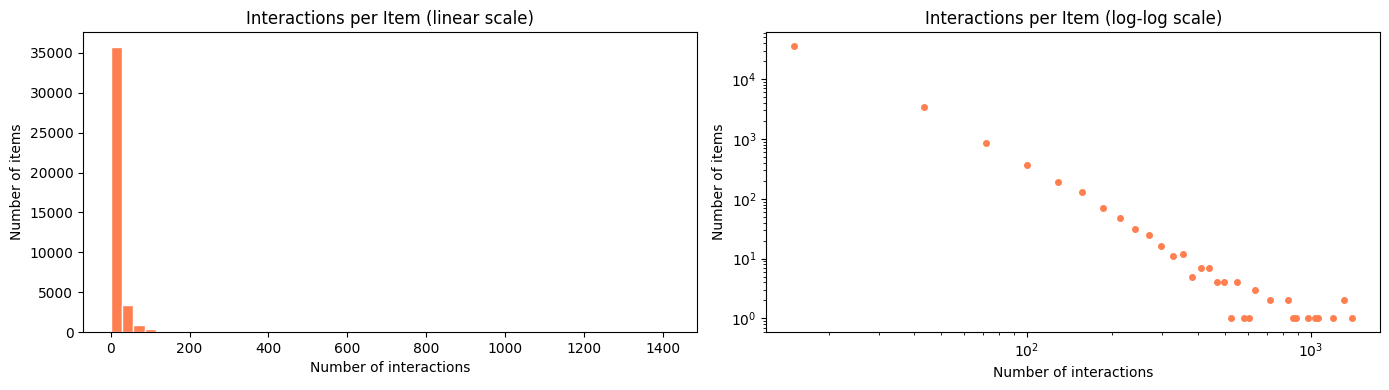

In [20]:
item_counter = Counter(item for _, item in train_pairs)
item_degrees = np.array(list(item_counter.values()))

print(f"Min interactions per item : {item_degrees.min()}")
print(f"Max interactions per item : {item_degrees.max()}")
print(f"Mean                      : {item_degrees.mean():.1f}")
print(f"Median                    : {np.median(item_degrees):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(item_degrees, bins=50, color="coral", edgecolor="white")
axes[0].set_title("Interactions per Item (linear scale)")
axes[0].set_xlabel("Number of interactions")
axes[0].set_ylabel("Number of items")

counts, edges = np.histogram(item_degrees, bins=50)
centers = (edges[:-1] + edges[1:]) / 2
axes[1].loglog(centers[counts > 0], counts[counts > 0], "o", color="coral", markersize=4)
axes[1].set_title("Interactions per Item (log-log scale)")
axes[1].set_xlabel("Number of interactions")
axes[1].set_ylabel("Number of items")

plt.tight_layout()
plt.show()

## 5. Train / Test Split Analysis

The authors split the data into two sets:
- **Train** (78.9%) — interactions the model learns from
- **Test** (21.1%) — interactions the model has never seen, used only to measure final performance

Two things we verify here:

1. **No test user is missing from train** — if a user appears only in the test set, the model
   has never seen them and cannot generate any embedding for them. All 29,858 test users must
   also be in training. Result: 0 missing (good).

2. **How many test items per user** — on average 7.3 items per user in the test set.
   During evaluation, for each user we will ask the model to rank all 40,981 items
   and check whether the true test items land in the top 20. This is the **all-ranking protocol**
   described in Section 4.1 of the paper.

In [21]:
test_sizes = np.array([len(items) for items in test_user_items.values()])

print(f"Users with test interactions : {len(test_user_items):,}")
print(f"Min test items per user      : {test_sizes.min()}")
print(f"Max test items per user      : {test_sizes.max()}")
print(f"Mean test items per user     : {test_sizes.mean():.1f}")

test_users_not_in_train = set(test_user_items.keys()) - set(train_user_items.keys())
print(f"\nTest users missing from train: {len(test_users_not_in_train)} (should be 0)")

print(f"\nTrain: {n_train:,} interactions ({100*n_train/n_interactions:.1f}%)")
print(f"Test:  {n_test:,}  interactions ({100*n_test/n_interactions:.1f}%)")

Users with test interactions : 29,858
Min test items per user      : 1
Max test items per user      : 203
Mean test items per user     : 7.3

Test users missing from train: 0 (should be 0)

Train: 810,128 interactions (78.9%)
Test:  217,242  interactions (21.1%)


## 6. Sparsity Visualization

Numbers are one thing — seeing it is another. Here we visualize what the interaction matrix
actually looks like.

The full matrix R has 29,858 rows (users) × 40,981 columns (items) = **over 1.2 billion cells**.
Out of those, only 810,128 are filled with a 1. Everything else is 0.

We sample the first 200 users and 200 items and draw a heatmap — each blue dot is a known
interaction, white space is the unknown. The result looks almost entirely white, which is exactly
the point: **the model must learn to predict which of those white cells should actually be blue**,
i.e. which places a user would likely visit even though we have no record of it yet.

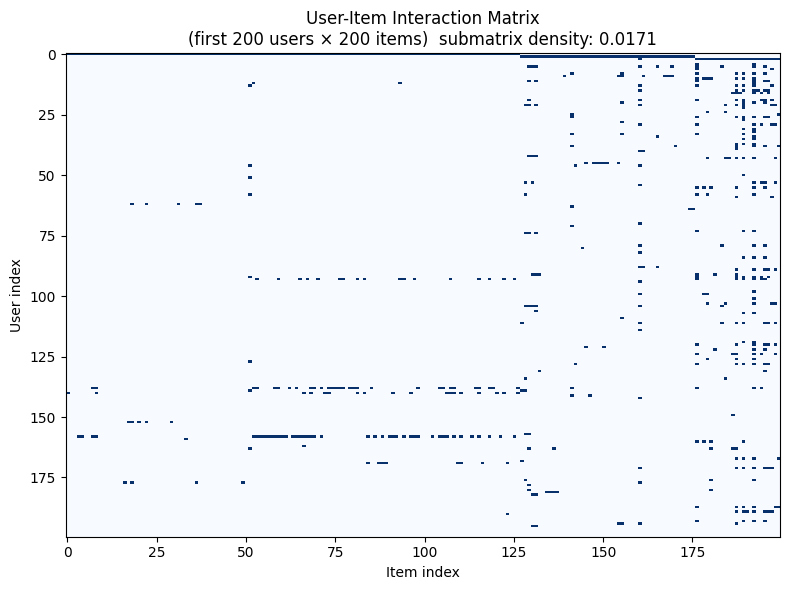

In [22]:
SAMPLE_USERS = 200
SAMPLE_ITEMS = 200

sampled_users = sorted(list(train_user_items.keys()))[:SAMPLE_USERS]
sampled_items = sorted(list(all_items_train))[:SAMPLE_ITEMS]
item_to_col = {item: col for col, item in enumerate(sampled_items)}

matrix = np.zeros((SAMPLE_USERS, SAMPLE_ITEMS), dtype=np.uint8)
for row, user in enumerate(sampled_users):
    for item in train_user_items[user]:
        if item in item_to_col:
            matrix[row, item_to_col[item]] = 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(matrix, cmap="Blues", aspect="auto", interpolation="none")
ax.set_title(
    f"User-Item Interaction Matrix\n"
    f"(first {SAMPLE_USERS} users × {SAMPLE_ITEMS} items)  "
    f"submatrix density: {matrix.mean():.4f}"
)
ax.set_xlabel("Item index")
ax.set_ylabel("User index")
plt.tight_layout()
plt.show()

## 7. Summary

A final side-by-side comparison of our loaded data against Table 2 from the paper.

All four numbers match exactly — users, items, total interactions, and density.
This confirms that we have the correct dataset, correctly loaded, and are ready to
proceed to building the model on top of it.

In [23]:
summary = pd.DataFrame({
    "Metric": ["Users", "Items", "Interactions", "Density"],
    "Our data": [f"{n_users:,}", f"{n_items:,}", f"{n_interactions:,}", f"{density:.5f}"],
    "Paper (Table 2)": ["29,858", "40,981", "1,027,370", "0.00084"]
})
print(summary.to_string(index=False))

      Metric  Our data Paper (Table 2)
       Users    29,858          29,858
       Items    40,981          40,981
Interactions 1,027,370       1,027,370
     Density   0.00084         0.00084
